# Chapter 15b: Graph Analytics

**Level 4: Expert** · ⏱ about 2.5 hours · Dataset: *Supply chain network* (30 facilities, 43 routes)

### What you will learn

1. When a question needs a **graph algorithm** instead of a query
2. How the **Stardog Spark connector** runs algorithms and writes results back as **triples**
3. Five algorithms (**PageRank**, **Connected Components**, **Strongly Connected Components**, **Label Propagation**, **Triangle Count**) and what each means for a supply chain
4. **Combining** algorithm results with the rest of the graph in SPARQL, including a risk map from Chapter 12's coordinates
5. **What-if analysis** with scenario graphs
6. Running analytics in practice: runtime, scale, refresh

This chapter is the tutorial version of the separate `supply_chain/` project, rebuilt on the tutorial's own modules.

### Requirements

The connector runs **on your machine** and talks to Stardog Cloud over HTTP. It needs the files in the project's `tools/` folder (see the project README): the connector jar (which bundles Spark), a portable **Java 11**, and on Windows **Hadoop's winutils**. Each algorithm run takes 20–40 seconds, mostly Spark starting up.

In [1]:
import sys
from pathlib import Path

TUTORIAL = Path('..').resolve()
if str(TUTORIAL / 'src') not in sys.path:
    sys.path.insert(0, str(TUTORIAL / 'src'))

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import stardog

from kg import analytics, client, sparql

pd.set_option('display.max_colwidth', 60)
conn = client.connect()
PREFIX = 'urn:tutorial:ch15b'
NETWORK = f'{PREFIX}:network'
SC = 'http://example.org/supplychain#'

with client.transaction(conn) as stats:
    conn.clear(graph_uri=NETWORK)
    conn.add(stardog.content.File(str(TUTORIAL / 'data' / 'supply_chain' / 'network.ttl')), graph_uri=NETWORK)
print('network loaded:', stats, '| tools:', analytics.tools_available())

P = '''PREFIX sc:  <http://example.org/supplychain#>
PREFIX geo: <http://www.opengis.net/ont/geosparql#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
'''
def result_graph(algorithm):
    return f'{PREFIX}:analytics:{algorithm}'

network loaded: {'added': 498, 'removed': 0} | tools: {'connector jar': True, 'java 11': True, 'hadoop winutils': True}


## 15b.1 Queries answer local questions; algorithms answer global ones

"Which stores does the Chicago DC serve?" is **local**: follow a few edges from one node. "Which facility is most **critical** to the whole network?" is **global**: the answer for one node depends on the shape of **everything**.

Let's try the obvious SPARQL answer first, **degree**: how many routes go in and out of each facility:

In [2]:
degree = sparql.run_query(conn, P + '''
SELECT ?id ?name (COUNT(DISTINCT ?in) AS ?in_degree) (COUNT(DISTINCT ?out) AS ?out_degree)
WHERE {
  ?f sc:name ?name .
  OPTIONAL { ?in sc:shipsTo ?f }
  OPTIONAL { ?f sc:shipsTo ?out }
  BIND(STRAFTER(STR(?f), "#") AS ?id)
}
GROUP BY ?id ?name
ORDER BY DESC(?in_degree) ?name''', graphs=NETWORK)
degree.head(8)

,id,name,in_degree,out_degree
0,F2,Pune Assembly Plant,4,1
1,RC1,Memphis Returns Center,3,1
2,P5,Port of Los Angeles,3,1
3,P4,Port of Rotterdam,3,2
4,F1,Shenzhen Assembly Plant,3,2
5,R1,Berlin Store,2,0
6,R6,Chicago Store,2,1
7,DC5,Dallas Distribution Center,2,1


Degree counts **direct** neighbours only. A port that receives from just two big factories, whose output **all** the stores depend on, looks unimportant by degree. Questions like that need algorithms that consider the whole network, iteratively.

## 15b.2 How the Spark connector works

```
 your laptop                                                        Stardog Cloud
 ┌──────────────────────────────────────────────────────┐          ┌──────────────────────────┐
 │ kg.analytics.run(...)                                 │          │ urn:tutorial:ch15b:      │
 │   └─ java -jar stardog-spark-connector.jar            │ 1. edges │   network  (shipsTo)     │
 │        (Spark in local mode)  ──── CONSTRUCT query ───┼─────────►│                          │
 │        2. runs the algorithm                          │ 3. write │   analytics:<Algorithm>  │
 │        └────────── one triple per node ───────────────┼─────────►│   (node, property, value)│
 └──────────────────────────────────────────────────────┘          └──────────────────────────┘
```

1. A **`CONSTRUCT`** query selects the edges to analyse. Here, only `facility sc:shipsTo facility`, so names, cities and route details don't become part of the graph.
2. Spark runs the algorithm.
3. The connector writes **one triple per node** into an output graph: `facility <output property> value`.

Results are ordinary triples, so SPARQL can join them with everything else.

In [3]:
EDGES = analytics.edges_query(SC + 'shipsTo', [NETWORK])
print(EDGES)

construct { ?s <http://example.org/supplychain#shipsTo> ?o } from <urn:tutorial:ch15b:network> where { ?s <http://example.org/supplychain#shipsTo> ?o }


In [4]:
def run(algorithm, prop, iterations=10, edges=EDGES, graph=None):
    graph = graph or result_graph(algorithm)
    info = analytics.run(algorithm, edges, SC + prop, graph, iterations=iterations)
    print(f"{info['algorithm']}: {info['results written']} results in {info['seconds']} s -> {graph}")
    return graph

def results(prop, graph):
    return sparql.run_query(conn, P + f'''
    SELECT ?id ?name ?type ?value WHERE {{
      GRAPH <{graph}> {{ ?f sc:{prop} ?value }}
      GRAPH <{NETWORK}> {{ ?f sc:name ?name ; a ?t }}
      BIND(STRAFTER(STR(?f), "#") AS ?id) BIND(STRAFTER(STR(?t), "#") AS ?type)
    }}''').rename(columns={'value': prop})

## 15b.3 PageRank: criticality

A facility is important if important facilities ship **to** it. PageRank imagines a shipment wandering the network along routes (occasionally jumping at random) and measures where it spends its time.

In [5]:
run('PageRank', 'pageRank', iterations=20)
pagerank = results('pageRank', result_graph('PageRank'))
ranked = pagerank.merge(degree[['id', 'in_degree']], on='id').sort_values('pageRank', ascending=False)
ranked.head(8).round(3)

PageRank: 30 results in 27.1 s -> urn:tutorial:ch15b:analytics:PageRank


,id,name,type,pageRank,in_degree
21,F2,Pune Assembly Plant,Factory,2.303,4
20,P3,Port of Mumbai,Port,2.303,1
6,DC3,Los Angeles Distribution Center,DistributionCenter,1.992,1
24,P5,Port of Los Angeles,Port,1.938,3
23,P4,Port of Rotterdam,Port,1.938,3
12,RC1,Memphis Returns Center,ReturnsCenter,1.613,3
0,DC2,Frankfurt Distribution Center,DistributionCenter,1.417,2
2,R1,Berlin Store,RetailStore,1.196,2


Compare **PageRank** with **in-degree**. The Pune plant (F2) and the Port of Mumbai (P3) rank highest although they have few incoming routes (see `in_degree`); Mumbai has just one. The returns loop (US stores → Memphis → Pune) feeds importance back into them, something degree can't see.

## 15b.4 Connected Components: separate networks

Facilities connected by **any** route, ignoring direction, share a component ID:

In [6]:
run('ConnectedComponents', 'component')
components = results('component', result_graph('ConnectedComponents'))
components.groupby('component').agg(facilities=('id', 'count'), examples=('name', lambda n: ', '.join(sorted(n)[:3])))

ConnectedComponents: 30 results in 38.9 s -> urn:tutorial:ch15b:analytics:ConnectedComponents


,facilities,examples
component,,
0,25,"Amsterdam Store, Bangalore Chip Works, Berlin Store"
7,5,"Buenos Aires Store, Minas Gerais Coffee Farm, Rio de Jan..."


Two networks: the global electronics chain and the South American coffee chain. Nothing can flow between them, including disruptions.

## 15b.5 Strongly Connected Components: loops

Here **direction matters**: nodes are in the same component only if each can **reach** the other. Components with several members are **cycles**:

In [7]:
run('StronglyConnectedComponents', 'scc')
scc = results('scc', result_graph('StronglyConnectedComponents'))
in_loop = scc[scc.groupby('scc').id.transform('count') > 1].sort_values('id')
print(f'{scc.scc.nunique()} components; one loop of {len(in_loop)} facilities:')
in_loop[['id', 'name', 'type']]

StronglyConnectedComponents: 30 results in 28.1 s -> urn:tutorial:ch15b:analytics:StronglyConnectedComponents


23 components; one loop of 8 facilities:


,id,name,type
6,DC3,Los Angeles Distribution Center,DistributionCenter
5,DC4,Chicago Distribution Center,DistributionCenter
21,F2,Pune Assembly Plant,Factory
20,P3,Port of Mumbai,Port
24,P5,Port of Los Angeles,Port
10,R6,Chicago Store,RetailStore
11,R7,New York Store,RetailStore
12,RC1,Memphis Returns Center,ReturnsCenter


## 15b.6 Label Propagation: communities

Each node repeatedly adopts the most common label among its neighbours; densely connected groups converge on the same label. Results can vary slightly between runs (ties are broken arbitrarily), so treat communities as **exploratory**.

In [8]:
run('LabelPropagation', 'community')
communities = results('community', result_graph('LabelPropagation'))
(communities.sort_values('id').groupby('community')
            .agg(size=('id', 'count'), members=('id', ', '.join)).sort_values('size', ascending=False))

LabelPropagation: 30 results in 25.1 s -> urn:tutorial:ch15b:analytics:LabelPropagation


,size,members
community,,
2,12,"DC3, DC4, DC5, P1, P2, P3, R4, R5, R6, R7, R8, RC1"
11,4,"F1, F2, P4, P5"
29,4,"S1, S2, S3, S4"
17,3,"DC6, R9, S5"
26,3,"R1, R2, R3"
18,2,"DC1, DC2"
31,2,"F3, R10"


## 15b.7 Triangle Count: redundancy

Three facilities all linked to each other form a triangle: if one link fails, goods can still go around via the third. **Zero triangles** = no local detour:

In [9]:
run('TriangleCount', 'triangles', iterations=1)
triangles = results('triangles', result_graph('TriangleCount')).sort_values('triangles', ascending=False)
triangles.head(8)

TriangleCount: 30 results in 24.6 s -> urn:tutorial:ch15b:analytics:TriangleCount


,id,name,type,triangles
5,DC4,Chicago Distribution Center,DistributionCenter,4
0,DC2,Frankfurt Distribution Center,DistributionCenter,3
1,DC1,Rotterdam Distribution Center,DistributionCenter,3
17,P1,Port of Shanghai,Port,3
19,P2,Port of Singapore,Port,3
12,RC1,Memphis Returns Center,ReturnsCenter,2
10,R6,Chicago Store,RetailStore,2
23,P4,Port of Rotterdam,Port,2


## 15b.8 Combining results with the graph

All results now sit in the database as triples, next to names, types, **coordinates** (Chapter 12) and route **lead times**. One SPARQL query combines them into a risk table: **important** (high PageRank) **and fragile** (no triangles):

In [10]:
ALL = [NETWORK] + [result_graph(a) for a in ('PageRank', 'TriangleCount', 'StronglyConnectedComponents')]
risk = sparql.run_query(conn, P + '''
SELECT ?id ?name ?type ?lon ?lat ?rank ?triangles ?in_loop (MAX(?days) AS ?slowest_inbound_days)
WHERE {
  ?f sc:name ?name ; a ?t ; sc:pageRank ?rank ; sc:triangles ?triangles ; sc:scc ?c ;
     geo:hasGeometry/geo:asWKT ?wkt .
  OPTIONAL { ?r sc:destination ?f ; sc:leadTimeDays ?days }
  { SELECT ?c (COUNT(?m) > 1 AS ?in_loop) WHERE { ?m sc:scc ?c } GROUP BY ?c }
  BIND(STRAFTER(STR(?f), "#") AS ?id) BIND(STRAFTER(STR(?t), "#") AS ?type)
  BIND(xsd:decimal(STRBEFORE(STRAFTER(STR(?wkt), "POINT("), " ")) AS ?lon)
  BIND(xsd:decimal(STRBEFORE(STRAFTER(STR(?wkt), " "), ")")) AS ?lat)
}
GROUP BY ?id ?name ?type ?lon ?lat ?rank ?triangles ?in_loop
ORDER BY DESC(?rank)''', graphs=ALL)
threshold = risk['rank'].quantile(0.6)
risk['risk'] = 'low'
risk.loc[risk['rank'] >= threshold, 'risk'] = 'medium'
risk.loc[(risk['rank'] >= threshold) & (risk.triangles == 0), 'risk'] = 'HIGH'
risk[['id', 'name', 'rank', 'triangles', 'in_loop', 'slowest_inbound_days', 'risk']].head(10).round(3)

,id,name,rank,triangles,in_loop,slowest_inbound_days,risk
0,F2,Pune Assembly Plant,2.303,0,True,30.0,HIGH
1,P3,Port of Mumbai,2.303,0,True,1.0,HIGH
2,DC3,Los Angeles Distribution Center,1.992,2,True,1.0,medium
3,P5,Port of Los Angeles,1.938,1,True,28.0,medium
4,P4,Port of Rotterdam,1.938,2,False,30.0,medium
5,RC1,Memphis Returns Center,1.613,2,True,3.0,medium
6,DC2,Frankfurt Distribution Center,1.417,3,False,2.0,medium
7,R2,Paris Store,1.196,1,False,2.0,medium
8,R1,Berlin Store,1.196,1,False,2.0,medium
9,DC1,Rotterdam Distribution Center,1.169,3,False,1.0,medium


Coordinates were parsed from the WKT strings with plain string functions, so no spatial index is needed here. Plotted on longitude/latitude:

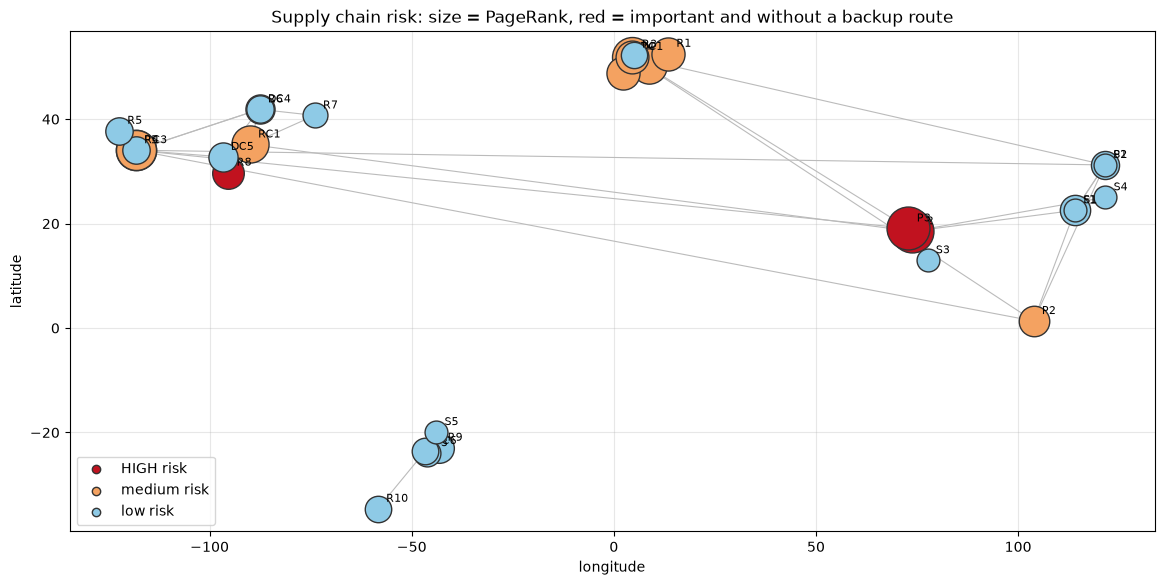

In [11]:
edges = sparql.run_query(conn, P + 'SELECT ?a ?b { ?x sc:shipsTo ?y BIND(STRAFTER(STR(?x), "#") AS ?a) BIND(STRAFTER(STR(?y), "#") AS ?b) }', graphs=NETWORK)
pos = {r.id: (float(r.lon), float(r.lat)) for r in risk.itertuples()}
colors = {'HIGH': '#c1121f', 'medium': '#f4a261', 'low': '#8ecae6'}

fig, ax = plt.subplots(figsize=(14, 6.5))
for e in edges.itertuples():
    (x1, y1), (x2, y2) = pos[e.a], pos[e.b]
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle='->', color='#bbbbbb', lw=0.8))
for r in risk.itertuples():
    ax.scatter(pos[r.id][0], pos[r.id][1], s=150 + 350 * r.rank, color=colors[r.risk], edgecolor='#333', zorder=3)
    ax.annotate(r.id, pos[r.id], textcoords='offset points', xytext=(6, 5), fontsize=8)
for label, c in colors.items():
    ax.scatter([], [], color=c, edgecolor='#333', label=f'{label} risk')
ax.legend(loc='lower left'); ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
ax.set_title('Supply chain risk: size = PageRank, red = important and without a backup route')
ax.grid(alpha=0.3); plt.show()

The biggest risk sits in **India**: the Pune plant and the Port of Mumbai are the most important nodes and have no detour. The smaller red dot in Texas is the **Houston store**: it's supplied only by the Dallas DC, with no alternative route, a single-source store.

## 15b.9 What-if: add backup routes

Would two new sea routes fix it: **Pune → Singapore** and **Mumbai → Singapore**? Put the new edges in a **scenario graph**, and run the algorithms on network + scenario. The real data stays untouched:

In [12]:
SCENARIO = f'{PREFIX}:scenario'
with client.transaction(conn):
    conn.clear(graph_uri=SCENARIO)
    conn.add(stardog.content.Raw(b'''@prefix sc: <http://example.org/supplychain#> .
        sc:F2 sc:shipsTo sc:P2 .  sc:P3 sc:shipsTo sc:P2 .''', 'text/turtle'), graph_uri=SCENARIO)

WHAT_IF_EDGES = analytics.edges_query(SC + 'shipsTo', [NETWORK, SCENARIO])
run('PageRank', 'pageRank', iterations=20, edges=WHAT_IF_EDGES, graph=f'{SCENARIO}:PageRank')
run('TriangleCount', 'triangles', iterations=1, edges=WHAT_IF_EDGES, graph=f'{SCENARIO}:TriangleCount')

after = results('pageRank', f'{SCENARIO}:PageRank')[['id', 'pageRank']].merge(
        results('triangles', f'{SCENARIO}:TriangleCount')[['id', 'triangles']], on='id')
before = risk[['id', 'name', 'rank', 'triangles']].rename(columns={'rank': 'PageRank before', 'triangles': 'triangles before'})
compare = before.merge(after.rename(columns={'pageRank': 'PageRank after', 'triangles': 'triangles after'}), on='id')
compare = compare[['id', 'name', 'PageRank before', 'PageRank after', 'triangles before', 'triangles after']]
compare[compare.id.isin(['F2', 'P3', 'P2', 'P4', 'P5'])].set_index('id').round(3)

PageRank: 30 results in 26.7 s -> urn:tutorial:ch15b:scenario:PageRank


TriangleCount: 30 results in 24.3 s -> urn:tutorial:ch15b:scenario:TriangleCount


,name,PageRank before,PageRank after,triangles before,triangles after
id,,,,,
F2,Pune Assembly Plant,2.303,2.283,0,1
P3,Port of Mumbai,2.303,1.313,0,3
P5,Port of Los Angeles,1.938,1.896,1,2
P4,Port of Rotterdam,1.938,1.896,2,3
P2,Port of Singapore,0.951,2.287,3,6


Pune and Mumbai now sit in triangles, so each has a detour. Mumbai's importance drops, because flow now splits between two ports, and Singapore picks it up. Scenarios are just **extra named graphs** in the `CONSTRUCT`: cheap to create, compare and throw away.

## 15b.10 Graph analytics in practice

| Topic | Advice |
|---|---|
| **Runtime** | Here 20–40 s per algorithm, almost all Spark start-up. On big graphs, run Spark on a cluster (`spark-submit --master …`) instead of `local[*]` |
| **Scope** | The `CONSTRUCT` decides what is analysed: one relationship type, one region, one time window. Smaller, cleaner input means faster and more meaningful results |
| **Iterations** | PageRank and Label Propagation iterate; raise `iterations` until results stop changing |
| **Output** | One named graph per algorithm (and per scenario), so reruns replace cleanly, old results can be compared, and permissions can differ |
| **Freshness** | Results are a **snapshot**. Schedule reruns when the network changes, and record when each graph was produced (PROV-O, Chapter 11) |
| **Reasoning** | The connector can run the `CONSTRUCT` with reasoning (`stardog.reasoning.schema=<model>`), e.g. to analyse inferred links |

> 🔁 **Neo4j equivalent:** the Neo4j Graph Data Science library runs these algorithms **inside** the database (`gds.pageRank.write(…)`), projecting the graph into memory first. Stardog delegates them to Spark, which scales out on a cluster and keeps the database free for queries.

## 15b.11 Exercises

**Exercise 1.** Run PageRank on the **reversed** network (`?o sc:shipsTo ?s` → edges pointing *upstream*). Which facilities become most important now, and what does "important" mean in that direction?

<details><summary>Solution</summary>

```python
reversed_edges = (f'construct {{ ?o <{SC}shipsTo> ?s }} from <{NETWORK}> where {{ ?s <{SC}shipsTo> ?o }}')
run('PageRank', 'pageRankUpstream', iterations=20, edges=reversed_edges, graph=f'{PREFIX}:analytics:upstream')
results('pageRankUpstream', f'{PREFIX}:analytics:upstream').sort_values('pageRankUpstream', ascending=False).head()
```
Now importance flows **towards suppliers**: facilities that many downstream flows depend on. It's a measure of upstream criticality.
</details>

**Exercise 2.** Run Connected Components on **sea routes only**. How many separate "sea networks" are there?

<details><summary>Solution</summary>

```python
sea = (f'construct {{ ?s <{SC}shipsTo> ?o }} from <{NETWORK}> '
       f'where {{ ?r <{SC}mode> "Sea" ; <{SC}origin> ?s ; <{SC}destination> ?o }}')
run('ConnectedComponents', 'seaComponent', edges=sea, graph=f'{PREFIX}:analytics:sea')
results('seaComponent', f'{PREFIX}:analytics:sea').groupby('seaComponent').id.apply(list)
```
Only facilities touched by sea routes get a value: the `CONSTRUCT` defines the graph.
</details>

**Exercise 3.** Write one SPARQL query listing facilities that are **on the returns loop** *and* have **zero triangles**.

<details><summary>Solution</summary>

```python
sparql.run_query(conn, P + '''SELECT ?name WHERE {
  ?f sc:name ?name ; sc:triangles 0 ; sc:scc ?c .
  { SELECT ?c WHERE { ?m sc:scc ?c } GROUP BY ?c HAVING (COUNT(?m) > 1) } }''', graphs=ALL)
```
</details>

In [13]:
# your answers here

## 15b.12 Clean up

In [14]:
CLEAN_UP = True

if CLEAN_UP:
    graphs = sparql.run_query(conn, f'SELECT DISTINCT ?g {{ GRAPH ?g {{ ?s ?p ?o }} FILTER(STRSTARTS(STR(?g), "{PREFIX}")) }}').g.tolist()
    with client.transaction(conn):
        for g in graphs:
            conn.clear(graph_uri=g)
    print(f'removed {len(graphs)} graphs')
conn.close()

removed 9 graphs


## Summary

- **Queries** answer local questions; **graph algorithms** compute global properties such as importance, connectivity, loops, communities and redundancy.
- The **Stardog Spark connector** reads edges with a `CONSTRUCT`, runs the algorithm in Spark, and writes **one triple per node** into an output graph (`kg.analytics.run`).
- **PageRank** ≠ degree: it captures importance flowing through the network. **Connected / strongly connected components** find separate networks and loops; **label propagation** finds communities; **triangle count** measures local redundancy.
- Results are triples, so **SPARQL joins** them with names, coordinates and lead times, e.g. into a risk table and map.
- **Scenarios** are extra named graphs in the `CONSTRUCT`: what-if analysis without touching real data.

**Next: Chapter 16, Knowledge graphs and LLMs (GraphRAG).** Natural-language questions answered from the graph: text-to-SPARQL grounded in the ontology with validation and retries, hybrid retrieval, and a comparison with Stardog Voicebox.